# Cross-Subject Comparison — Mathematics vs Portuguese
## Bachelor Thesis | UCI Student Performance Dataset (Cortez & Silva, 2008)
**Run this after both the Mathematics and Portuguese notebooks have been completed.**

Reads from `../results/` and generates 6 comparison plots + logistic regression coefficient analysis.


---
## Setup — Imports & Configuration

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 150

COLOR_MAT = "#4C72B0"   # blue  — Math
COLOR_POR = "#55A868"   # green — Portuguese
COLOR_ACC = "#C44E52"   # red   — accent / baseline

print("Setup complete.")

Setup complete.


---
## Load Results

In [47]:
mat_report = pd.read_csv("../results/mat_results_final_report.csv")
por_report = pd.read_csv("../results/por_results_final_report.csv")
mat_corr   = pd.read_csv("../results/mat_results_correlations.csv")
por_corr   = pd.read_csv("../results/por_results_correlations.csv")
mat_hyp    = pd.read_csv("../results/mat_results_hypothesis_tests.csv")
por_hyp    = pd.read_csv("../results/por_results_hypothesis_tests.csv")

print("All result files loaded successfully.")
print()
print("Mathematics report columns:", list(mat_report.columns))
print("Portuguese report columns: ", list(por_report.columns))

All result files loaded successfully.

Mathematics report columns: ['Model', 'Task', 'R²', 'MAE', 'RMSE', 'Accuracy', 'Precision', 'Recall', 'F1', 'CV Mean', 'CV Std', 'AUC-ROC']
Portuguese report columns:  ['Model', 'Task', 'R²', 'MAE', 'RMSE', 'Accuracy', 'Precision', 'Recall', 'F1', 'CV Mean', 'CV Std', 'AUC-ROC']


---
## Dataset Overview

In [48]:
print(f"  {'Metric':<35} {'Math':>10} {'Portuguese':>12}")
print(f"  {'-'*35} {'-'*10} {'-'*12}")
overview = [
    ("Total students",         "395",    "649"),
    ("Training samples (80%)", "316",    "519"),
    ("Test samples (20%)",     "79",     "130"),
    ("Features",               "36",     "39"),
    ("Mean final grade (G3)",  "10.42",  "11.91"),
    ("Std deviation",          "4.58",   "3.23"),
    ("Pass rate",              "67.1%",  "84.6%"),
    ("Naive baseline acc.",    "67.1%",  "84.6%"),
]
for label, mat, por in overview:
    print(f"  {label:<35} {mat:>10} {por:>12}")

  Metric                                    Math   Portuguese
  ----------------------------------- ---------- ------------
  Total students                             395          649
  Training samples (80%)                     316          519
  Test samples (20%)                          79          130
  Features                                    36           39
  Mean final grade (G3)                    10.42        11.91
  Std deviation                             4.58         3.23
  Pass rate                                67.1%        84.6%
  Naive baseline acc.                      67.1%        84.6%


---
## Model Metrics Comparison

In [49]:
for model in ["Logistic Regression", "Random Forest", "Neural Network"]:
    mat_row = mat_report[mat_report["Model"] == model].iloc[0]
    por_row = por_report[por_report["Model"] == model].iloc[0]
    print(f"  {model}:")
    print(f"    F1 Score   — Math: {mat_row['F1']}   Portuguese: {por_row['F1']}")
    print(f"    Accuracy   — Math: {mat_row['Accuracy']}   Portuguese: {por_row['Accuracy']}")
    print(f"    AUC-ROC    — Math: {mat_row['AUC-ROC']}   Portuguese: {por_row['AUC-ROC']}")
    print()

mat_lr = mat_report[mat_report["Model"] == "Linear Regression"].iloc[0]
por_lr = por_report[por_report["Model"] == "Linear Regression"].iloc[0]
print(f"  Linear Regression:")
print(f"    R²         — Math: {mat_lr['R²']}   Portuguese: {por_lr['R²']}")
print(f"    MAE        — Math: {mat_lr['MAE']}   Portuguese: {por_lr['MAE']}")
print(f"    RMSE       — Math: {mat_lr['RMSE']}   Portuguese: {por_lr['RMSE']}")

  Logistic Regression:
    F1 Score   — Math: 0.7965   Portuguese: 0.931
    Accuracy   — Math: 0.7089   Portuguese: 0.8769
    AUC-ROC    — Math: 0.7379   Portuguese: 0.7843

  Random Forest:
    F1 Score   — Math: 0.7769   Portuguese: 0.9383
    Accuracy   — Math: 0.6582   Portuguese: 0.8846
    AUC-ROC    — Math: 0.7261   Portuguese: 0.7916

  Neural Network:
    F1 Score   — Math: 0.7627   Portuguese: 0.8908
    Accuracy   — Math: 0.6456   Portuguese: 0.8077
    AUC-ROC    — Math: 0.6332   Portuguese: 0.6557

  Linear Regression:
    R²         — Math: 0.1415   Portuguese: 0.1602
    MAE        — Math: 3.3953   Portuguese: 2.1564
    RMSE       — Math: 4.1957   Portuguese: 2.8618


---
## Pearson Correlation Comparison

In [50]:
corr_merged = mat_corr.merge(por_corr, on="Variable", suffixes=("_mat", "_por"))
corr_merged["delta"] = corr_merged["r_por"] - corr_merged["r_mat"]
corr_merged = corr_merged.sort_values("r_mat", key=abs, ascending=False)

print(f"  {'Variable':<35} {'Math r':>8} {'Por r':>8} {'Delta':>8}")
print(f"  {'-'*35} {'-'*8} {'-'*8} {'-'*8}")
for _, row in corr_merged.iterrows():
    delta_str = f"+{row['delta']:.4f}" if row['delta'] >= 0 else f"{row['delta']:.4f}"
    print(f"  {row['Variable']:<35} {row['r_mat']:>8.4f} {row['r_por']:>8.4f} {delta_str:>8}")

  Variable                              Math r    Por r    Delta
  ----------------------------------- -------- -------- --------
  Past Class Failures                  -0.3604  -0.3933  -0.0329
  Mother's Education                    0.2171   0.2402  +0.0231
  Age                                  -0.1616  -0.1065  +0.0551
  Father's Education                    0.1525   0.2118  +0.0593
  Going Out with Friends               -0.1328  -0.0876  +0.0452
  Travel Time to School                -0.1171  -0.1272  -0.0101
  Weekly Study Time                     0.0978   0.2498  +0.1520
  Current Health Status                -0.0613  -0.0989  -0.0376
  Workday Alcohol Consumption          -0.0547  -0.2047  -0.1500
  Weekend Alcohol Consumption          -0.0519  -0.1766  -0.1247
  Family Relationship Quality           0.0514   0.0634  +0.0120
  Number of Absences                    0.0342  -0.0914  -0.1256
  Free Time After School                0.0113  -0.1227  -0.1340


---
## Plot 1 — F1 Score Comparison

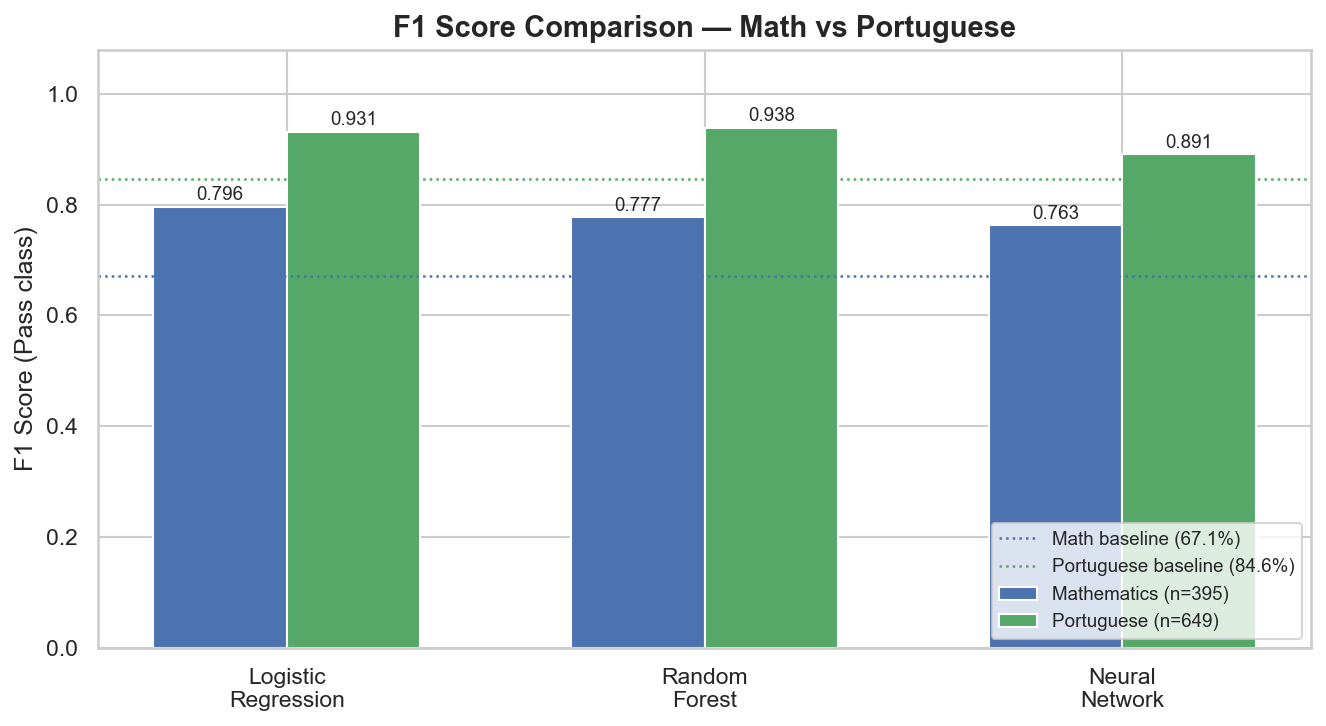

Saved: ../plots/comparison_plot1_model_f1.png


In [51]:
models = ["Logistic\nRegression", "Random\nForest", "Neural\nNetwork"]
f1_mat, f1_por = [], []
for m in ["Logistic Regression", "Random Forest", "Neural Network"]:
    f1_mat.append(float(mat_report[mat_report["Model"] == m]["F1"].values[0]))
    f1_por.append(float(por_report[por_report["Model"] == m]["F1"].values[0]))

x, width = np.arange(3), 0.32
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, f1_mat, width, label="Mathematics (n=395)", color=COLOR_MAT, edgecolor="white")
bars2 = ax.bar(x + width/2, f1_por, width, label="Portuguese (n=649)",  color=COLOR_POR, edgecolor="white")
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
ax.axhline(y=0.671, color=COLOR_MAT, linestyle=":", linewidth=1.2, label="Math baseline (67.1%)")
ax.axhline(y=0.846, color=COLOR_POR, linestyle=":", linewidth=1.2, label="Portuguese baseline (84.6%)")
ax.set_title("F1 Score Comparison — Math vs Portuguese", fontsize=14, fontweight="bold")
ax.set_ylabel("F1 Score (Pass class)", fontsize=12)
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.08); ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig("../plots/comparison_plot1_model_f1.png")
plt.show()
print("Saved: ../plots/comparison_plot1_model_f1.png")

---
## Plot 2 — Classification Metrics Panel (2×2)

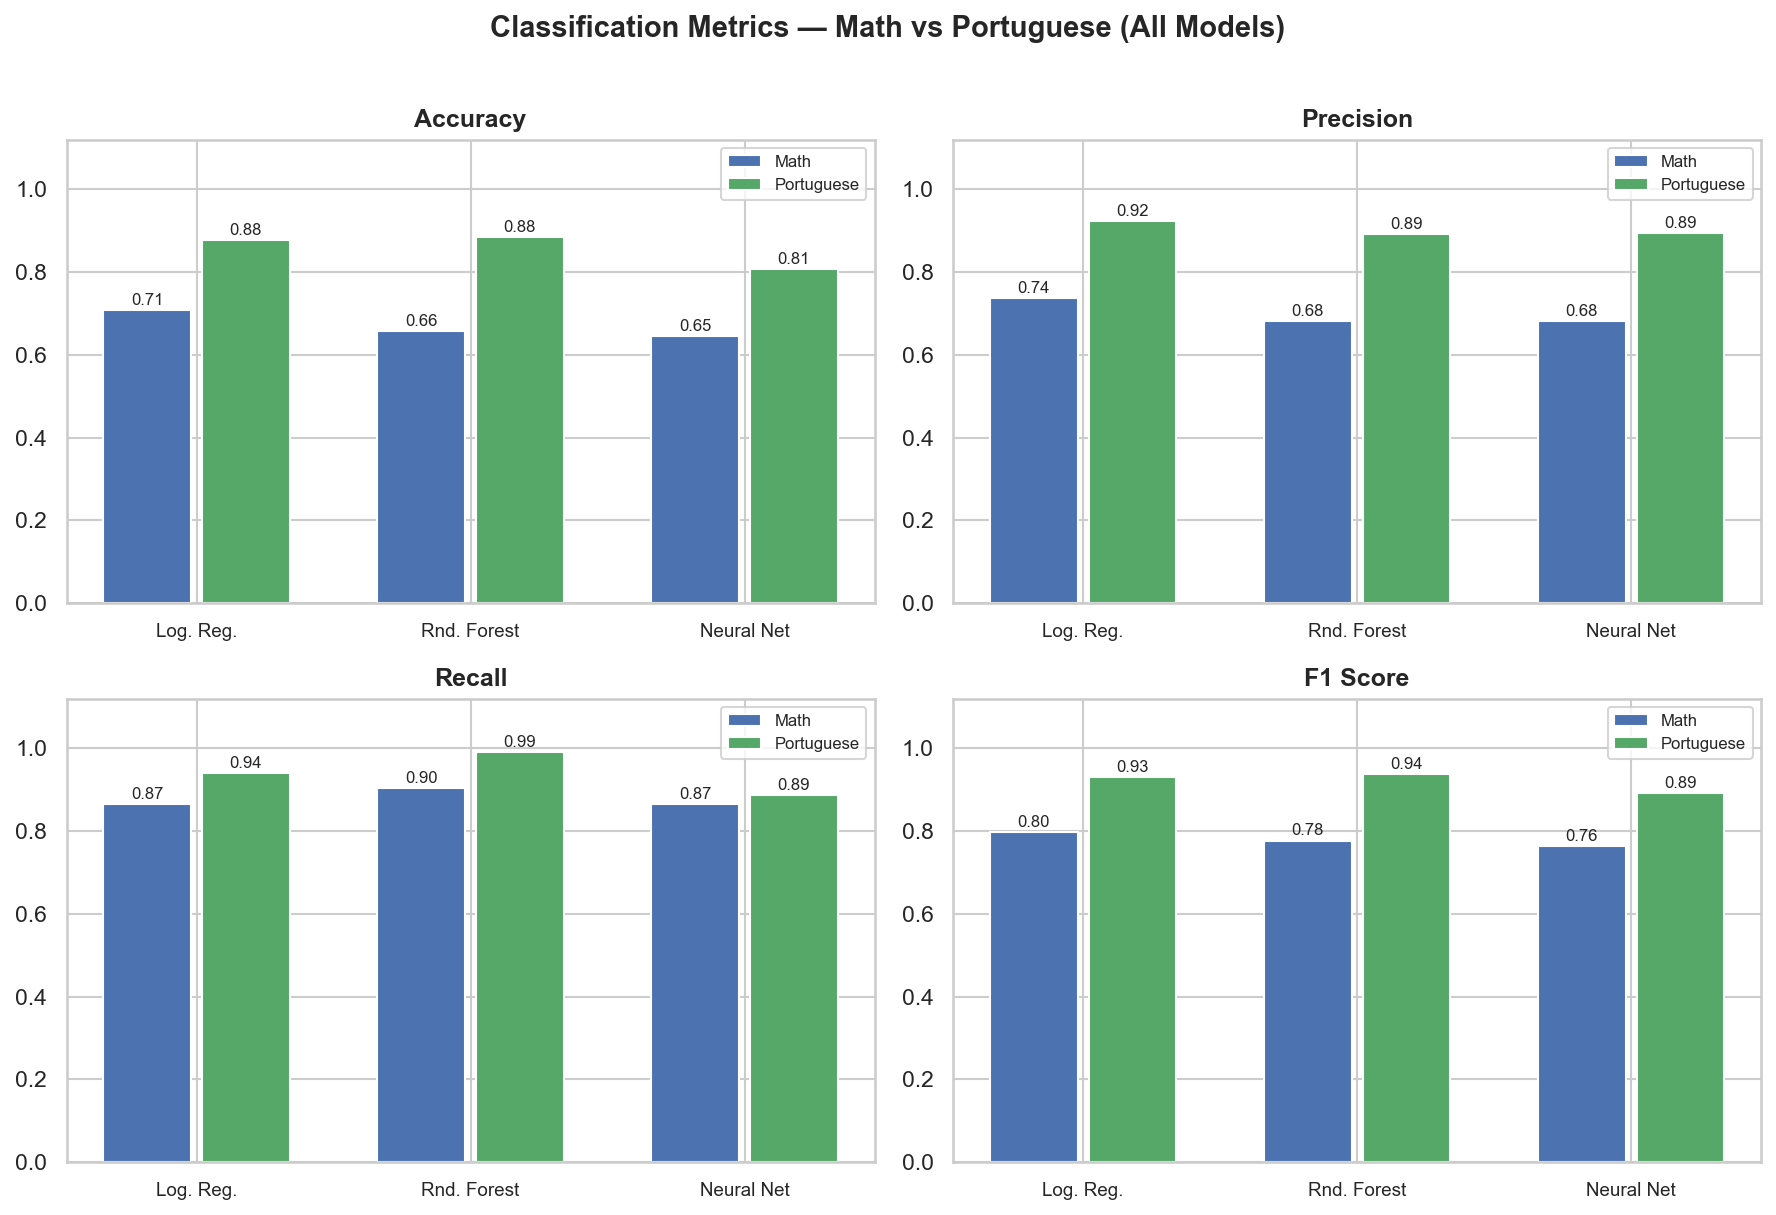

Saved: ../plots/comparison_plot2_all_metrics.png


In [52]:
metric_labels = ["Accuracy", "Precision", "Recall", "F1 Score"]
metric_keys   = ["Accuracy", "Precision", "Recall", "F1"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for idx, (label, key) in enumerate(zip(metric_labels, metric_keys)):
    ax = axes[idx]
    mat_vals, por_vals = [], []
    for m in ["Logistic Regression", "Random Forest", "Neural Network"]:
        mat_vals.append(float(mat_report[mat_report["Model"] == m][key].values[0]))
        por_vals.append(float(por_report[por_report["Model"] == m][key].values[0]))
    x = np.arange(3)
    b1 = ax.bar(x-0.18, mat_vals, 0.32, label="Math",       color=COLOR_MAT, edgecolor="white")
    b2 = ax.bar(x+0.18, por_vals, 0.32, label="Portuguese", color=COLOR_POR, edgecolor="white")
    for bars in [b1, b2]:
        for bar in bars:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(["Log. Reg.", "Rnd. Forest", "Neural Net"], fontsize=9)
    ax.set_ylim(0, 1.12); ax.legend(fontsize=8)
fig.suptitle("Classification Metrics — Math vs Portuguese (All Models)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../plots/comparison_plot2_all_metrics.png", bbox_inches="tight")
plt.show()
print("Saved: ../plots/comparison_plot2_all_metrics.png")

---
## Plot 3 — Pearson Correlation Comparison

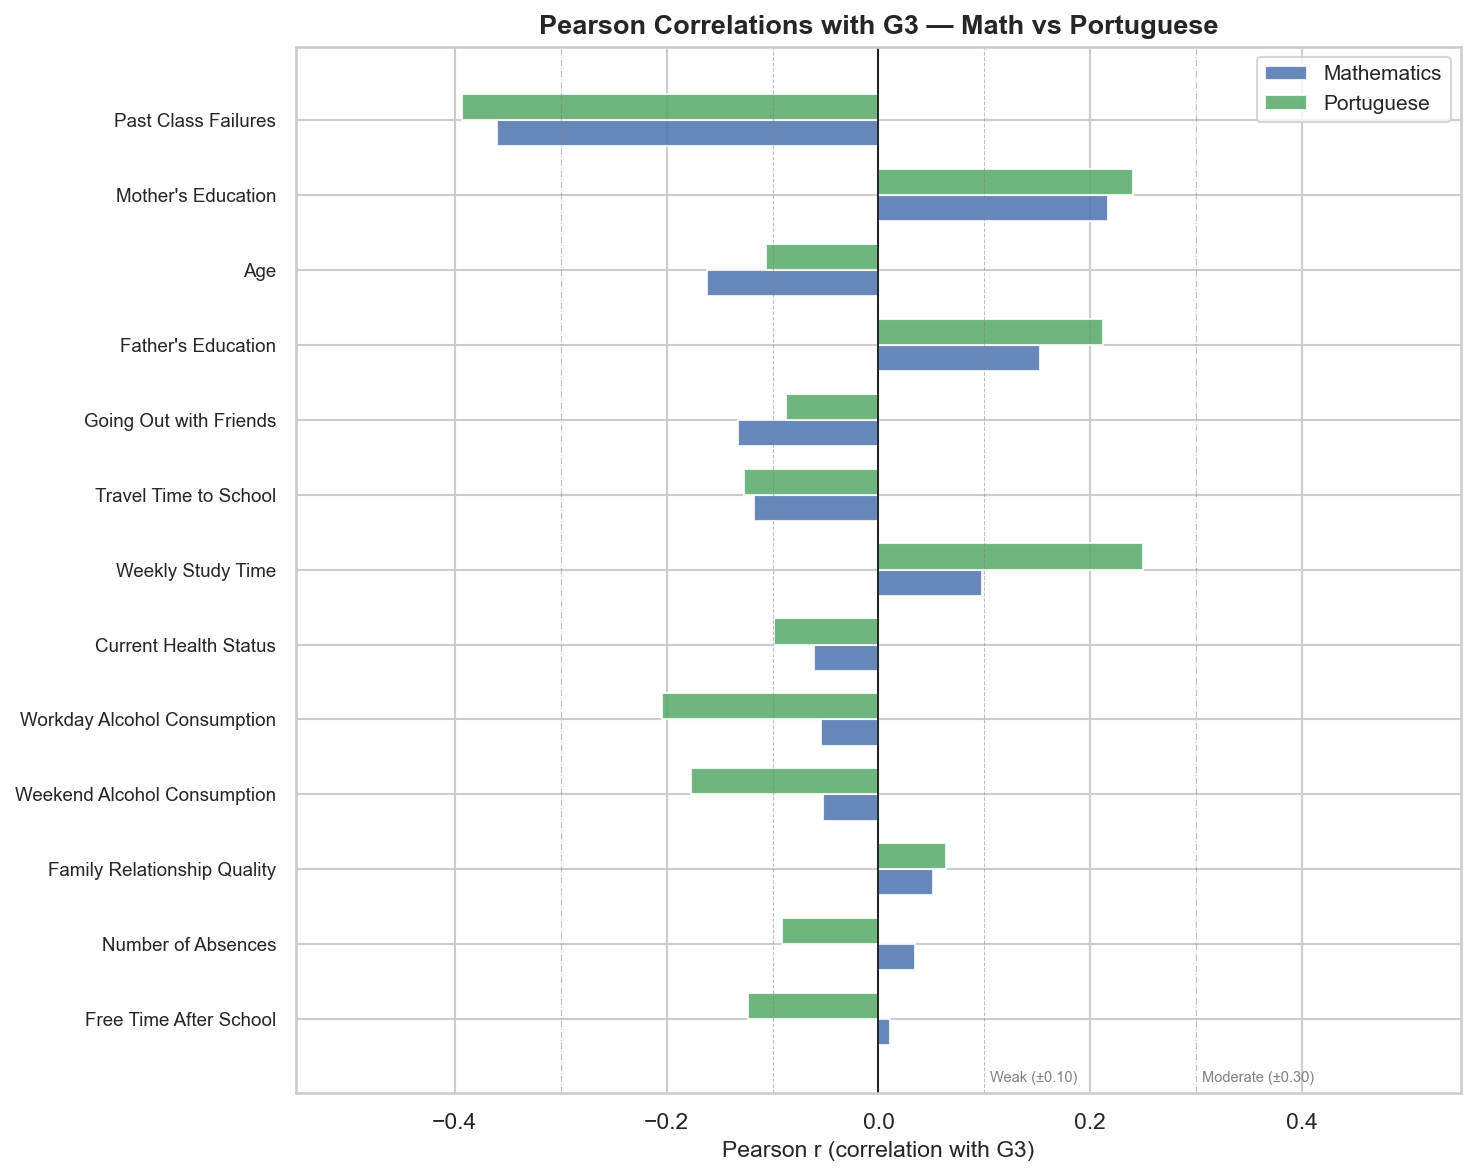

Saved: ../plots/comparison_plot3_correlations.png


In [53]:
vars_ordered = corr_merged.sort_values("r_mat", key=abs, ascending=True)["Variable"].tolist()
r_mat_vals   = corr_merged.set_index("Variable").loc[vars_ordered, "r_mat"].tolist()
r_por_vals   = corr_merged.set_index("Variable").loc[vars_ordered, "r_por"].tolist()

y, height = np.arange(len(vars_ordered)), 0.35
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(y-height/2, r_mat_vals, height, label="Mathematics", color=COLOR_MAT, edgecolor="white", alpha=0.85)
ax.barh(y+height/2, r_por_vals, height, label="Portuguese",  color=COLOR_POR, edgecolor="white", alpha=0.85)
ax.axvline(x=0,     color="black", linewidth=0.8)
ax.axvline(x=0.10,  color="gray",  linewidth=0.5, linestyle="--", alpha=0.5)
ax.axvline(x=-0.10, color="gray",  linewidth=0.5, linestyle="--", alpha=0.5)
ax.axvline(x=0.30,  color="gray",  linewidth=0.5, linestyle="-.", alpha=0.5)
ax.axvline(x=-0.30, color="gray",  linewidth=0.5, linestyle="-.", alpha=0.5)
ax.set_yticks(y); ax.set_yticklabels(vars_ordered, fontsize=9)
ax.set_xlabel("Pearson r (correlation with G3)", fontsize=11)
ax.set_title("Pearson Correlations with G3 — Math vs Portuguese", fontsize=13, fontweight="bold")
ax.legend(fontsize=10); ax.set_xlim(-0.55, 0.55)
ax.text(0.105, -0.7, "Weak (±0.10)",     fontsize=7, color="gray", va="top")
ax.text(0.305, -0.7, "Moderate (±0.30)", fontsize=7, color="gray", va="top")
plt.tight_layout()
plt.savefig("../plots/comparison_plot3_correlations.png")
plt.show()
print("Saved: ../plots/comparison_plot3_correlations.png")

---
## Plot 4 — Hypothesis Test Effect Sizes (Cohen's d)

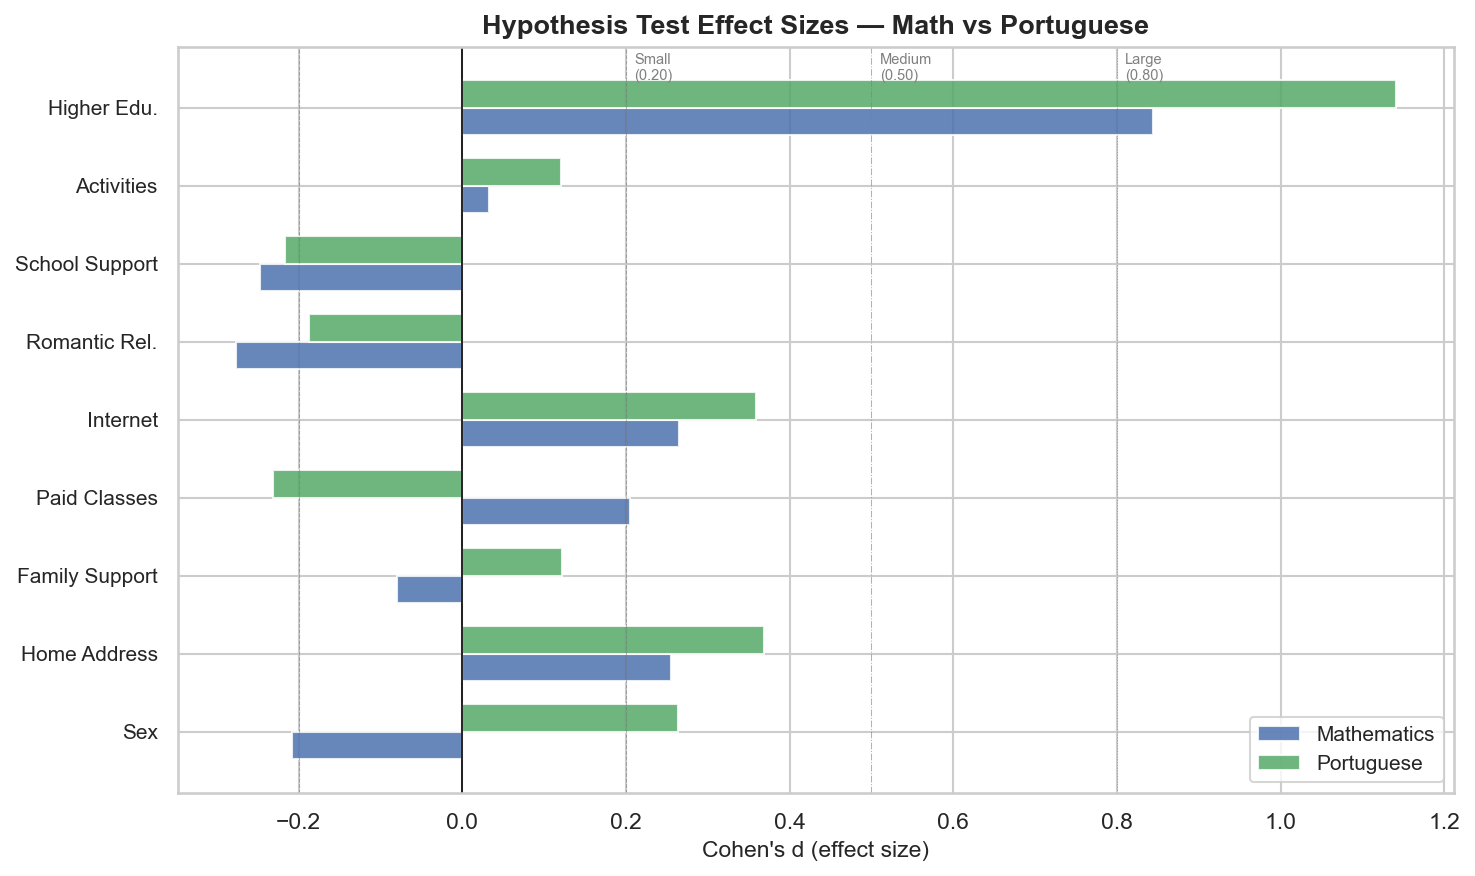

Saved: ../plots/comparison_plot4_effect_sizes.png


In [54]:
hyp_vars = mat_hyp["Variable"].tolist()
mat_d = mat_hyp.set_index("Variable")["Cohen's d"].reindex(hyp_vars).tolist()
por_d = por_hyp.set_index("Variable")["Cohen's d"].reindex(hyp_vars).fillna(0).tolist()

short_labels = ["Sex", "Home Address", "Family Support", "Paid Classes",
                "Internet", "Romantic Rel.", "School Support", "Activities", "Higher Edu."]

y, height = np.arange(len(short_labels)), 0.35
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y-height/2, mat_d, height, label="Mathematics", color=COLOR_MAT, edgecolor="white", alpha=0.85)
ax.barh(y+height/2, por_d, height, label="Portuguese",  color=COLOR_POR, edgecolor="white", alpha=0.85)
ax.axvline(x=0,    color="black", linewidth=0.8)
ax.axvline(x=0.20,  color="gray", linewidth=0.5, linestyle="--", alpha=0.6)
ax.axvline(x=-0.20, color="gray", linewidth=0.5, linestyle="--", alpha=0.6)
ax.axvline(x=0.50,  color="gray", linewidth=0.5, linestyle="-.", alpha=0.6)
ax.axvline(x=0.80,  color="gray", linewidth=0.5, linestyle=":",  alpha=0.6)
ax.set_yticks(y); ax.set_yticklabels(short_labels, fontsize=10)
ax.set_xlabel("Cohen's d (effect size)", fontsize=11)
ax.set_title("Hypothesis Test Effect Sizes — Math vs Portuguese", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
for xval, lbl in [(0.21, "Small\n(0.20)"), (0.51, "Medium\n(0.50)"), (0.81, "Large\n(0.80)")]:
    ax.text(xval, len(short_labels)-0.3, lbl, fontsize=7, color="gray", va="top")
plt.tight_layout()
plt.savefig("../plots/comparison_plot4_effect_sizes.png")
plt.show()
print("Saved: ../plots/comparison_plot4_effect_sizes.png")

---
## Plot 5 — Linear Regression Metrics

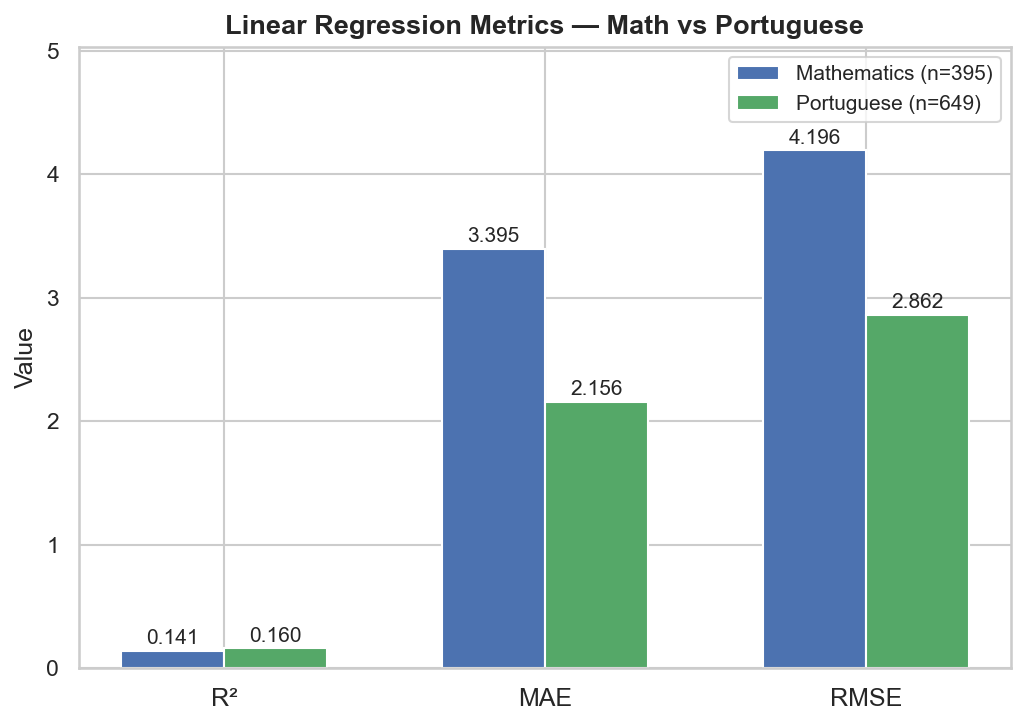

Saved: ../plots/comparison_plot5_regression.png


In [55]:
reg_metrics  = ["R²", "MAE", "RMSE"]
mat_reg_vals = [float(mat_lr["R²"]), float(mat_lr["MAE"]), float(mat_lr["RMSE"])]
por_reg_vals = [float(por_lr["R²"]), float(por_lr["MAE"]), float(por_lr["RMSE"])]

x, width = np.arange(3), 0.32
fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x-width/2, mat_reg_vals, width, label="Mathematics (n=395)", color=COLOR_MAT, edgecolor="white")
bars2 = ax.bar(x+width/2, por_reg_vals, width, label="Portuguese (n=649)",  color=COLOR_POR, edgecolor="white")
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)
ax.set_title("Linear Regression Metrics — Math vs Portuguese", fontsize=13, fontweight="bold")
ax.set_ylabel("Value", fontsize=12)
ax.set_xticks(x); ax.set_xticklabels(reg_metrics, fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, max(mat_reg_vals+por_reg_vals)*1.2)
plt.tight_layout()
plt.savefig("../plots/comparison_plot5_regression.png")
plt.show()
print("Saved: ../plots/comparison_plot5_regression.png")

---
## Plot 6 — Cross-Validation Stability

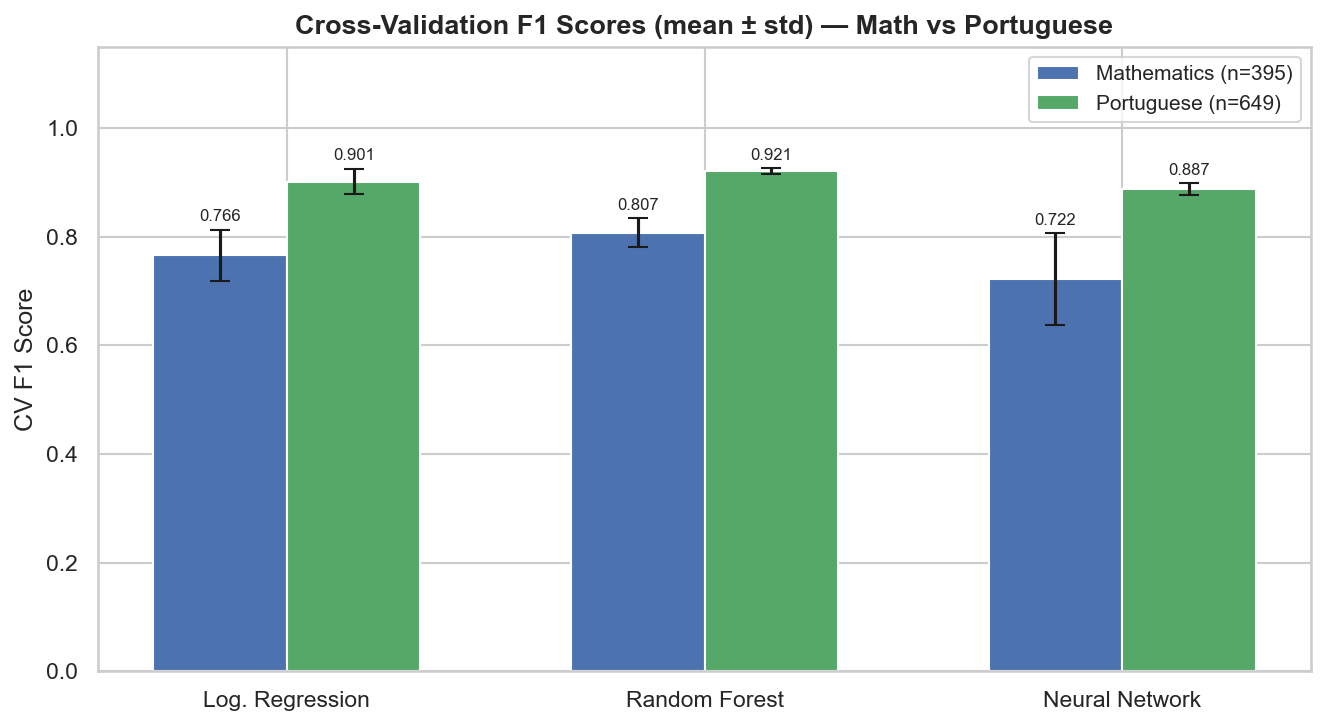

Saved: ../plots/comparison_plot6_cv_stability.png

Neural Network CV std: Math=0.0842  Portuguese=0.0112
=> Same architecture becomes dramatically more stable with more data.


In [56]:
mat_cv_means, mat_cv_stds, por_cv_means, por_cv_stds = [], [], [], []
for m in ["Logistic Regression", "Random Forest", "Neural Network"]:
    mat_cv_means.append(float(mat_report[mat_report["Model"] == m]["CV Mean"].values[0]))
    mat_cv_stds.append( float(mat_report[mat_report["Model"] == m]["CV Std"].values[0]))
    por_cv_means.append(float(por_report[por_report["Model"] == m]["CV Mean"].values[0]))
    por_cv_stds.append( float(por_report[por_report["Model"] == m]["CV Std"].values[0]))

x, width = np.arange(3), 0.32
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x-width/2, mat_cv_means, width, yerr=mat_cv_stds,
       label="Mathematics (n=395)", color=COLOR_MAT, edgecolor="white",
       capsize=5, error_kw={"linewidth": 1.5})
ax.bar(x+width/2, por_cv_means, width, yerr=por_cv_stds,
       label="Portuguese (n=649)",  color=COLOR_POR, edgecolor="white",
       capsize=5, error_kw={"linewidth": 1.5})
for i, (mm, pm) in enumerate(zip(mat_cv_means, por_cv_means)):
    ax.text(i-width/2, mm+mat_cv_stds[i]+0.01, f"{mm:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i+width/2, pm+por_cv_stds[i]+0.01, f"{pm:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_title("Cross-Validation F1 Scores (mean ± std) — Math vs Portuguese",
             fontsize=13, fontweight="bold")
ax.set_ylabel("CV F1 Score", fontsize=12)
ax.set_xticks(x); ax.set_xticklabels(["Log. Regression", "Random Forest", "Neural Network"], fontsize=11)
ax.set_ylim(0, 1.15); ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../plots/comparison_plot6_cv_stability.png")
plt.show()
print("Saved: ../plots/comparison_plot6_cv_stability.png")
print()
print(f"Neural Network CV std: Math={mat_cv_stds[2]:.4f}  Portuguese={por_cv_stds[2]:.4f}")
print("=> Same architecture becomes dramatically more stable with more data.")

---
## Save Comparison Summary CSV

In [57]:
rows = []
for m in ["Linear Regression", "Logistic Regression", "Random Forest", "Neural Network"]:
    mat_row = mat_report[mat_report["Model"] == m].iloc[0]
    por_row = por_report[por_report["Model"] == m].iloc[0]
    rows.append({
        "Model":         m,
        "Math R²":       mat_row["R²"],
        "Por R²":        por_row["R²"],
        "Math MAE":      mat_row["MAE"],
        "Por MAE":       por_row["MAE"],
        "Math RMSE":     mat_row["RMSE"],
        "Por RMSE":      por_row["RMSE"],
        "Math Accuracy": mat_row["Accuracy"],
        "Por Accuracy":  por_row["Accuracy"],
        "Math F1":       mat_row["F1"],
        "Por F1":        por_row["F1"],
        "Math AUC-ROC":  mat_row["AUC-ROC"],
        "Por AUC-ROC":   por_row["AUC-ROC"],
        "Math CV Mean":  mat_row["CV Mean"],
        "Math CV Std":   mat_row["CV Std"],
        "Por CV Mean":   por_row["CV Mean"],
        "Por CV Std":    por_row["CV Std"],
    })
pd.DataFrame(rows).to_csv("../results/comparison_results_summary.csv", index=False)
print("Saved: ../results/comparison_results_summary.csv")

Saved: ../results/comparison_results_summary.csv


---
## Logistic Regression Coefficients — Both Subjects

In [58]:
LR_LABELS = {
    "age": "Age", "Medu": "Mother's Education", "Fedu": "Father's Education",
    "traveltime": "Travel Time to School", "studytime": "Weekly Study Time",
    "failures": "Past Class Failures", "famrel": "Family Relationship Quality",
    "freetime": "Free Time After School", "goout": "Going Out with Friends",
    "Dalc": "Workday Alcohol Consumption", "Walc": "Weekend Alcohol Consumption",
    "health": "Current Health Status", "absences": "Number of Absences",
    "paid_yes": "Paid Extra Classes", "schoolsup_yes": "Extra School Support",
    "famsup_yes": "Family Educational Support", "activities_yes": "Extracurricular Activities",
    "internet_yes": "Internet Access at Home", "romantic_yes": "In a Romantic Relationship",
    "nursery_yes": "Attended Nursery School", "higher_yes": "Wants Higher Education",
    "address_U": "Urban Home Address", "famsize_LE3": "Small Family Size",
    "Pstatus_T": "Parents Living Together", "sex_M": "Sex (Male)",
    "school_MS": "School (Mousinho da Silveira)",
}

def get_lr_coefficients(csv_path):
    df = pd.read_csv(csv_path)
    exclude_cols = ["G3", "pass_fail", "G1", "G2"]
    feature_cols = [c for c in df.columns if c not in exclude_cols]
    X = df[feature_cols]
    y = df["pass_fail"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_sc, y_train)
    coef_df = pd.DataFrame({
        "Feature": [LR_LABELS.get(c, c) for c in feature_cols],
        "Coefficient": lr.coef_[0]
    })
    coef_df["Abs_Coef"] = coef_df["Coefficient"].abs()
    return coef_df.sort_values("Coefficient", ascending=False).reset_index(drop=True)

mat_coef = get_lr_coefficients("../data/student_mat_preprocessed.csv")
por_coef = get_lr_coefficients("../data/student_por_preprocessed.csv")

for name, coef_df in [("MATHEMATICS", mat_coef), ("PORTUGUESE", por_coef)]:
    print(f"{'='*60}")
    print(f"LOGISTIC REGRESSION COEFFICIENTS — {name}")
    print(f"{'='*60}")
    print(f"\nTop 8 POSITIVE (predict PASS):")
    print(f"{'Feature':<35} {'Coefficient':>12}")
    print("-" * 50)
    for _, row in coef_df[coef_df["Coefficient"] > 0].head(8).iterrows():
        print(f"{row['Feature']:<35} {row['Coefficient']:>12.4f}")
    print(f"\nTop 8 NEGATIVE (predict FAIL):")
    print(f"{'Feature':<35} {'Coefficient':>12}")
    print("-" * 50)
    for _, row in coef_df[coef_df["Coefficient"] < 0].tail(8).sort_values("Coefficient").iterrows():
        print(f"{row['Feature']:<35} {row['Coefficient']:>12.4f}")
    print()

mat_coef.to_csv("../results/mat_results_lr_coefficients.csv", index=False)
por_coef.to_csv("../results/por_results_lr_coefficients.csv", index=False)
print("Coefficient CSVs saved.")

LOGISTIC REGRESSION COEFFICIENTS — MATHEMATICS

Top 8 POSITIVE (predict PASS):
Feature                              Coefficient
--------------------------------------------------
Weekend Alcohol Consumption               0.4857
Wants Higher Education                    0.2480
Sex (Male)                                0.2356
Mjob_health                               0.2307
Mjob_services                             0.2219
Mother's Education                        0.1653
Weekly Study Time                         0.1493
Fjob_teacher                              0.1485

Top 8 NEGATIVE (predict FAIL):
Feature                              Coefficient
--------------------------------------------------
Past Class Failures                      -0.9788
Going Out with Friends                   -0.5148
Mjob_teacher                             -0.3717
Extra School Support                     -0.3500
Attended Nursery School                  -0.2331
guardian_mother                          -0.2253
Mjo

---
## Key Cross-Subject Findings Summary

In [59]:
print("=" * 65)
print("KEY CROSS-SUBJECT FINDINGS")
print("=" * 65)
print()

# 1. Neural Network stability
mat_nn_mean = mat_report[mat_report["Model"] == "Neural Network"]["CV Mean"].values[0]
mat_nn_std  = mat_report[mat_report["Model"] == "Neural Network"]["CV Std"].values[0]
por_nn_mean = por_report[por_report["Model"] == "Neural Network"]["CV Mean"].values[0]
por_nn_std  = por_report[por_report["Model"] == "Neural Network"]["CV Std"].values[0]
print("1. DATASET SIZE EFFECT ON NEURAL NETWORK")
print(f"   Math CV F1:       {mat_nn_mean:.4f} ± {mat_nn_std:.4f}")
print(f"   Portuguese CV F1: {por_nn_mean:.4f} ± {por_nn_std:.4f}")
print(f"   Neural Network variance drops sharply with more data.")
print()

# 2. Best model switches
print("2. BEST MODEL SWITCHES BETWEEN SUBJECTS")
print(f"   Math:       Logistic Regression wins  (F1 = {f1_mat[0]:.4f})")
print(f"   Portuguese: Random Forest wins        (F1 = {f1_por[1]:.4f})")
print(f"   More data allows RF to exploit non-linear patterns.")
print()

# 3. Study time
mat_st = mat_corr[mat_corr["Variable"] == "Weekly Study Time"]["r"].values[0]
por_st = por_corr[por_corr["Variable"] == "Weekly Study Time"]["r"].values[0]
print("3. STUDY TIME CORRELATION DIFFERS")
print(f"   Math r = {mat_st}  (not significant)")
print(f"   Por  r = {por_st}  (significant, p < 0.001)")
print(f"   Consistent effort more predictive for language than Math.")
print()

# 4. Educational aspiration
mat_he = mat_hyp[mat_hyp["Variable"] == "Wants Higher Education"]["Cohen's d"].values[0]
por_he = por_hyp[por_hyp["Variable"] == "Wants Higher Education"]["Cohen's d"].values[0]
print("4. EDUCATIONAL ASPIRATION EFFECT STRONGER IN PORTUGUESE")
print(f"   Math Cohen's d = {mat_he}")
print(f"   Por  Cohen's d = {por_he}")
print(f"   Large effect in both; strongest predictor across both subjects.")
print()

# 5. Past failures
mat_f = mat_corr[mat_corr["Variable"] == "Past Class Failures"]["r"].values[0]
por_f = por_corr[por_corr["Variable"] == "Past Class Failures"]["r"].values[0]
print("5. PAST FAILURES: CONSISTENT ACROSS BOTH SUBJECTS")
print(f"   Math r = {mat_f}")
print(f"   Por  r = {por_f}")
print(f"   Strongest numeric predictor in both subjects.")
print()
print("All files saved to ../plots/ and ../results/")

KEY CROSS-SUBJECT FINDINGS

1. DATASET SIZE EFFECT ON NEURAL NETWORK
   Math CV F1:       0.7222 ± 0.0842
   Portuguese CV F1: 0.8874 ± 0.0112
   Neural Network variance drops sharply with more data.

2. BEST MODEL SWITCHES BETWEEN SUBJECTS
   Math:       Logistic Regression wins  (F1 = 0.7965)
   Portuguese: Random Forest wins        (F1 = 0.9383)
   More data allows RF to exploit non-linear patterns.

3. STUDY TIME CORRELATION DIFFERS
   Math r = 0.0978  (not significant)
   Por  r = 0.2498  (significant, p < 0.001)
   Consistent effort more predictive for language than Math.

4. EDUCATIONAL ASPIRATION EFFECT STRONGER IN PORTUGUESE
   Math Cohen's d = 0.844
   Por  Cohen's d = 1.141
   Large effect in both; strongest predictor across both subjects.

5. PAST FAILURES: CONSISTENT ACROSS BOTH SUBJECTS
   Math r = -0.3604
   Por  r = -0.3933
   Strongest numeric predictor in both subjects.

All files saved to ../plots/ and ../results/
